                     traffic_volume
timestamp                          
2026-01-01 00:00:00             129
2026-01-01 01:00:00             117
2026-01-01 02:00:00             132
2026-01-01 03:00:00             150
2026-01-01 04:00:00             115


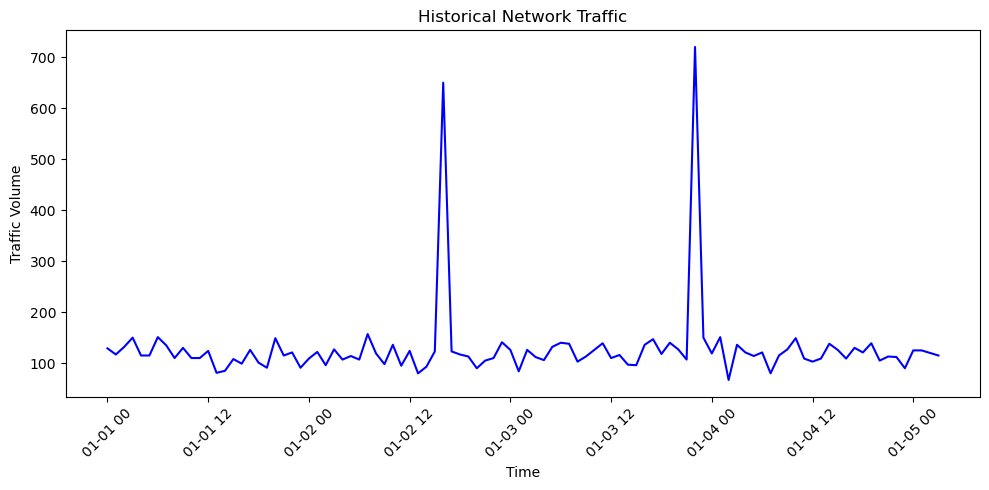

/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)



Forecasted Traffic
            timestamp  forecasted_traffic
0 2026-01-05 04:00:00          128.195839
1 2026-01-05 05:00:00          128.893352
2 2026-01-05 06:00:00          128.189075
3 2026-01-05 07:00:00          128.685596
4 2026-01-05 08:00:00          128.338797
5 2026-01-05 09:00:00          128.580951
6 2026-01-05 10:00:00          128.411868
7 2026-01-05 11:00:00          128.529929
8 2026-01-05 12:00:00          128.447493
9 2026-01-05 13:00:00          128.505054


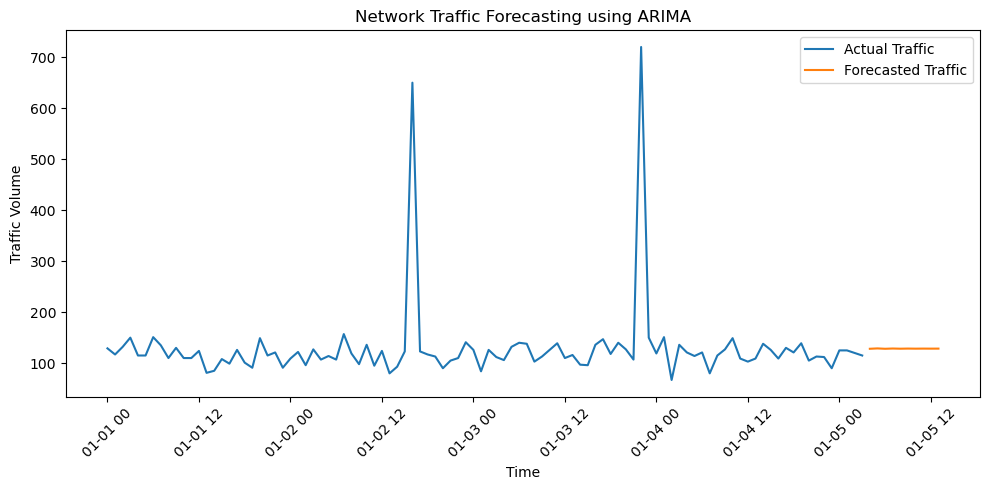


Detection Results
            timestamp  forecasted_traffic          status
0 2026-01-05 04:00:00          128.195839  Normal Traffic
1 2026-01-05 05:00:00          128.893352  Normal Traffic
2 2026-01-05 06:00:00          128.189075  Normal Traffic
3 2026-01-05 07:00:00          128.685596  Normal Traffic
4 2026-01-05 08:00:00          128.338797  Normal Traffic
5 2026-01-05 09:00:00          128.580951  Normal Traffic
6 2026-01-05 10:00:00          128.411868  Normal Traffic
7 2026-01-05 11:00:00          128.529929  Normal Traffic
8 2026-01-05 12:00:00          128.447493  Normal Traffic
9 2026-01-05 13:00:00          128.505054  Normal Traffic

Alerts
2026-01-05 04:00:00  -  Normal Traffic
2026-01-05 05:00:00  -  Normal Traffic
2026-01-05 06:00:00  -  Normal Traffic
2026-01-05 07:00:00  -  Normal Traffic
2026-01-05 08:00:00  -  Normal Traffic
2026-01-05 09:00:00  -  Normal Traffic
2026-01-05 10:00:00  -  Normal Traffic
2026-01-05 11:00:00  -  Normal Traffic
2026-01-05 12:00:00  - 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------
# Generate Sample Network Traffic Data
# -----------------------------
np.random.seed(42)

dates = pd.date_range(start="2026-01-01", periods=100, freq="h")

traffic = np.random.normal(loc=120, scale=20, size=100).astype(int)

# Add artificial DDoS spikes
traffic[40] = 650
traffic[70] = 720

data = pd.DataFrame({
    "timestamp": dates,
    "traffic_volume": traffic
})

# Save dataset
data.to_csv("network_traffic.csv", index=False)

# -----------------------------
# Load Dataset
# -----------------------------
data = pd.read_csv("network_traffic.csv")

data["timestamp"] = pd.to_datetime(data["timestamp"])
data.set_index("timestamp", inplace=True)

print(data.head())

# -----------------------------
# Plot Historical Traffic
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(data.index, data["traffic_volume"], color="blue")
plt.title("Historical Network Traffic")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# Train ARIMA Model
# -----------------------------
model = ARIMA(data["traffic_volume"], order=(2,1,2))
model_fit = model.fit()

# -----------------------------
# Forecast Next 10 Hours
# -----------------------------
forecast_steps = 10

forecast = model_fit.forecast(steps=forecast_steps)

future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_steps,
    freq="h"
)

forecast_df = pd.DataFrame({
    "timestamp": future_dates,
    "forecasted_traffic": forecast.values
})

print("\nForecasted Traffic")
print(forecast_df)

# -----------------------------
# Plot Actual vs Forecast
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(
    data.index,
    data["traffic_volume"],
    label="Actual Traffic"
)

plt.plot(
    forecast_df["timestamp"],
    forecast_df["forecasted_traffic"],
    label="Forecasted Traffic"
)

plt.title("Network Traffic Forecasting using ARIMA")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# Detect Possible DDoS
# -----------------------------
threshold = 500

forecast_df["status"] = forecast_df["forecasted_traffic"].apply(
    lambda x: "Possible DDoS Attack" if x > threshold else "Normal Traffic"
)

print("\nDetection Results")
print(forecast_df)

# -----------------------------
# Print Alerts
# -----------------------------
print("\nAlerts")

for _, row in forecast_df.iterrows():
    print(
        row["timestamp"],
        " - ",
        row["status"]
    )